In [60]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Correlation across all genes

In [91]:
# Configuration and paths
min_range = -100
max_range = +0

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)

# If expression prediction, then keep false
abs_phenotypes = False

config_path = "/home/dnanexus/ukbgym/config_olink.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Read the variant consequence configuration
records = []
for group, consequences in config["variant_consequences"].items():
    for consequence in consequences:
        records.append({'variant_class': group, 'vep_consequence': consequence})
var_cons = pl.DataFrame(records)

# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()
anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""plof""","""loftee_hc""","""#1f77b4""","""LOFTEE HC""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""missense""","""am_pathogenicity""","""#e76e5b""","""AlphaMissense""",-1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",1
"""conservation""","""gpn_star_llr_calibrated_mean""","""#942c80""","""GPN-Star""",-1
…,…,…,…,…
"""splicing""","""delta_score""","""#00A99D""","""SpliceAI""",-1
"""splicing""","""absplice_dna_max""","""#28a745""","""AbSplice (max)""",-1
"""splicing""","""absplice2_max""","""#1E8449""","""AbSplice2 (max)""",-1


In [92]:
# abs_phenotypes = True
# anno_config_df = anno_config_df.filter(pl.col('category').is_in(['genetic_diversity', 'conservation']))
abs_phenotypes = False
anno_config_df = anno_config_df.filter(pl.col('category').is_in(['regulatory']))
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()
anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""regulatory""","""promoterai""","""#00A99D""","""PromoterAI""",1
"""regulatory""","""abexp_min""","""#00A99D""","""AbExp min""",1


In [93]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_variants_union_annotated_250928.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

# Filter variant classes
group_name = "missense"
consequences_for_group = var_cons.filter(
    pl.col('variant_class') == group_name
)['vep_consequence'].to_list()
filter_expression = pl.any_horizontal(
    (pl.col(c) == 1) for c in consequences_for_group if c in anno.collect_schema().names()
)

anno_wide = (
    anno
    .filter(
        # filter_expression
        # (pl.col('consequence_splice_acceptor_variant') == 1) | (pl.col('consequence_splice_donor_variant') == 1)
        (pl.col('dist_to_tss') >= min_range) &
        (pl.col('dist_to_tss') <= max_range)
    )
    .select(
        set(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    .drop_nulls()
)

anno_wide

id,TSS,gene_name,dist_to_tss,Strand,region,gene_length,promoterai,abexp_min
str,i64,str,i64,cat,str,i64,f32,f64
"""chr2:213152427:C:A""",213152427,"""IKZF2""",0,"""-""","""ENSG00000030419""",152738,-0.0324,-0.012924
"""chr2:168901237:G:A""",168901290,"""G6PC2""",-53,"""+""","""ENSG00000152254""",8711,0.0195,-0.001024
"""chr2:212538931:G:A""",212538841,"""ERBB4""",-90,"""-""","""ENSG00000178568""",1163126,-0.0949,-0.003532
"""chr2:169031358:A:C""",169031324,"""ABCB11""",-34,"""-""","""ENSG00000073734""",115828,-0.0584,-0.01906
"""chr2:213152471:G:C""",213152427,"""IKZF2""",-44,"""-""","""ENSG00000030419""",152738,-0.0061,0.002372
…,…,…,…,…,…,…,…,…
"""chr11:17351702:C:T""",17351799,"""NCR3LG1""",-97,"""+""","""ENSG00000188211""",25543,0.0598,-0.006197
"""chr11:17351760:G:T""",17351799,"""NCR3LG1""",-39,"""+""","""ENSG00000188211""",25543,0.0155,-0.005749
"""chr16:88977251:C:T""",88977207,"""CBFA2T3""",-44,"""-""","""ENSG00000129993""",102351,-0.0488,0.000079


In [94]:
# new_anno = pl.scan_parquet("/home/dnanexus/data_dir/abexp1.1_annotations_all_ukb_vars_genebass1e6.parquet")
# # new_anno.head().collect()
# new_anno = new_anno.select(['id', 'region', 'abexp_whole_blood']).collect()
# new_anno = new_anno.filter(pl.col('abexp_whole_blood').is_not_null())

# anno_wide = anno_wide.join(new_anno, on=['id', 'region'], how='left').filter(pl.col('abexp_whole_blood').is_not_null())

# existing_annos += ['abexp_whole_blood']

# anno_wide

In [95]:
melted_anno = anno_wide.unpivot(
    index=["id", "region"],
    on=existing_annos,
    variable_name="annotation",
    value_name="annotation_score"
).with_columns(
    pl.col("annotation_score").cast(pl.Float32),
    pl.col("region").cast(pl.Utf8),
)
melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr2:213152427:C:A""","""ENSG00000030419""","""promoterai""",-0.0324
"""chr2:168901237:G:A""","""ENSG00000152254""","""promoterai""",0.0195
"""chr2:212538931:G:A""","""ENSG00000178568""","""promoterai""",-0.0949
"""chr2:169031358:A:C""","""ENSG00000073734""","""promoterai""",-0.0584
"""chr2:213152471:G:C""","""ENSG00000030419""","""promoterai""",-0.0061
…,…,…,…
"""chr11:17351702:C:T""","""ENSG00000188211""","""abexp_min""",-0.006197
"""chr11:17351760:G:T""","""ENSG00000188211""","""abexp_min""",-0.005749
"""chr16:88977251:C:T""","""ENSG00000129993""","""abexp_min""",0.000079


In [96]:
# Read Olink phenotype data
olink_appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_371olink_rint_corrected90pcs_EUR.parquet")

appv = (
    olink_appv
    .rename({
        'phenotype': 'olink_prot',
        'mean_pheno_value': 'mean_olink_value',
        'std_pheno_value': 'std_olink_value',
    })
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .with_columns(
        mean_olink_value = pl.when(abs_phenotypes)
        .then(pl.col('mean_olink_value').abs())
        .otherwise(pl.col('mean_olink_value'))
    )
)

# Merge phenotype data and annotation data
pg_df = (
    appv
    .join(
        melted_anno.lazy(), 
        on="id", 
        how="inner"
    )
    .filter(
        pl.col('region') + '_olink' == pl.col('olink_prot')
    )
    .join(
        anno.select(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']).lazy(), 
        on=['id', 'region'],
        how='inner'
    )
    .collect(engine='streaming')
)

# Join with experimental data
# pg_df = pg_df.join(exp_data.filter(pl.col('gene_name') == gene_name), on='id', how='inner')
pg_df

id,olink_prot,n_individuals,mean_olink_value,std_olink_value,region,annotation,annotation_score,TSS,Strand,gene_length,gene_name,dist_to_tss
str,str,u64,f32,f32,str,str,f32,i64,cat,i64,str,i64
"""chr6:109382476:C:A""","""ENSG00000135535_olink""",68,-0.195392,0.973567,"""ENSG00000135535""","""promoterai""",-0.1874,109382467,"""-""",15955,"""CD164""",-9
"""chr6:109382476:C:A""","""ENSG00000135535_olink""",68,-0.195392,0.973567,"""ENSG00000135535""","""abexp_min""",-0.003532,109382467,"""-""",15955,"""CD164""",-9
"""chr2:120013057:T:C""","""ENSG00000115109_olink""",8,0.206568,1.205655,"""ENSG00000115109""","""promoterai""",0.1066,120013076,"""+""",166044,"""EPB41L5""",-19
"""chr2:120013057:T:C""","""ENSG00000115109_olink""",8,0.206568,1.205655,"""ENSG00000115109""","""abexp_min""",-0.013111,120013076,"""+""",166044,"""EPB41L5""",-19
"""chr6:109382532:A:G""","""ENSG00000135535_olink""",1,1.007241,null,"""ENSG00000135535""","""promoterai""",0.0748,109382467,"""-""",15955,"""CD164""",-65
…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr11:10308216:A:C""","""ENSG00000133805_olink""",6,-0.092668,0.95033,"""ENSG00000133805""","""abexp_min""",-0.003532,10308312,"""+""",199268,"""AMPD3""",-96
"""chr9:114587616:A:C""","""ENSG00000136888_olink""",2,-0.462883,null,"""ENSG00000136888""","""promoterai""",0.0754,114587705,"""+""",11211,"""ATP6V1G1""",-89
"""chr9:114587616:A:C""","""ENSG00000136888_olink""",2,-0.462883,null,"""ENSG00000136888""","""abexp_min""",0.002221,114587705,"""+""",11211,"""ATP6V1G1""",-89


In [97]:
pg_df['mean_olink_value'].min()

-3.7749948501586914

In [98]:
pg_df['annotation'].value_counts(sort=True)

annotation,count
str,u64
"""promoterai""",3719
"""abexp_min""",3719


## Correlation across all genes

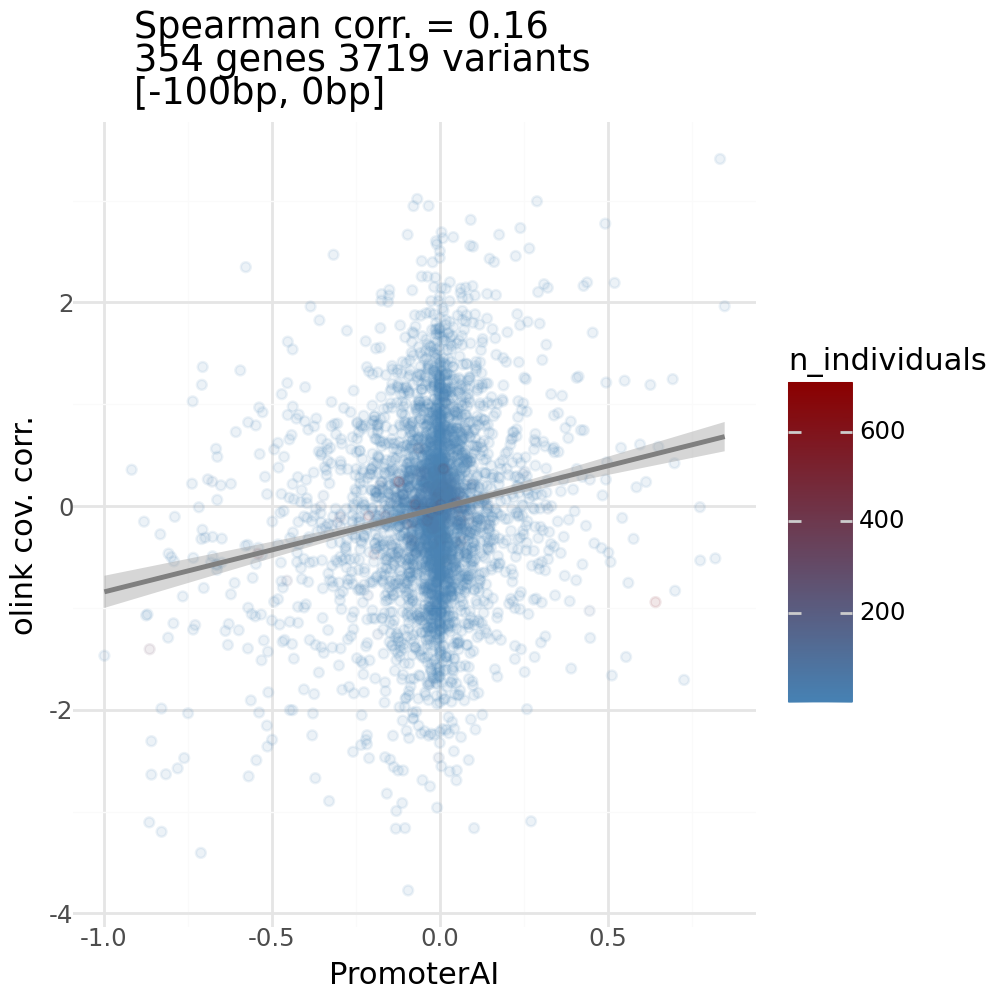

In [99]:
annotation = 'promoterai'
# annotation = 'gpn_star_llr_calibrated_mean'
# annotation = 'abexp_whole_blood'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    pg_df
    .filter(
        # (pl.col('gene_name') == gene_name) &
        (pl.col('annotation') == annotation)
    )
)

(
    ggplot(plot_df, aes(x='annotation_score', y='mean_olink_value', color='n_individuals')) +
    geom_point(alpha=0.1) +
    geom_smooth(method='glm', se=True, color='gray') +
    scale_color_gradient(low='steelblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"olink cov. corr.",
        title=f"Spearman corr. = {plot_df.select(pl.corr('annotation_score', 'mean_olink_value')).to_series()[0]:.2f} \
        \n{pg_df['gene_name'].n_unique()} genes {plot_df.shape[0]} variants \
        \n[{min_range}bp, {max_range}bp]"
    ) +
    theme(figure_size=(5, 5))
)

# Correlation per gene

In [100]:
corr_df = (
    pg_df
    .with_columns(
        pl.col(c)
        .rank("average")
        .over(["region", "gene_name", "olink_prot", "annotation"])
        .alias(f"{c}_rank")
        for c in ['mean_olink_value', 'annotation_score']
    )
    .group_by(["region", "gene_name", "olink_prot", "annotation"])
    .agg(
        n_variants = pl.col("id").count(),
        correlation = pl.corr("annotation_score_rank", "mean_olink_value_rank", propagate_nans=True)
    )
    .join(
        anno_config_df, on='annotation'
    )
    .with_columns(
        corr_beta = pl.col('correlation')*pl.col('annotation_dir')
    )
)

filt_corr_df = corr_df.filter(~pl.col('category').is_in(['missense', 'plof', 'naive', 'splicing']))
# filt_corr_df = corr_df.filter(~pl.col('category').is_in(['regulatory', 'plof', 'naive', 'missense']))

consistent_genes = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .group_by(['region', 'gene_name'])
    .agg(n_annotations = pl.len())
    .sort('n_annotations', descending=True)
    # .filter(pl.col('n_annotations') == filt_corr_df['annotation'].n_unique())
)

filt_corr_df = filt_corr_df.join(consistent_genes, on=['region', 'gene_name'], how='inner')
filt_corr_df = filt_corr_df.filter(pl.col('n_annotations') == filt_corr_df['annotation'].n_unique())
filt_corr_df

region,gene_name,olink_prot,annotation,n_variants,correlation,category,color,label,annotation_dir,corr_beta,n_annotations
str,str,str,str,u64,f64,str,str,str,i64,f64,u64
"""ENSG00000198610""","""AKR1C4""","""ENSG00000198610_olink""","""abexp_min""",7,0.0,"""regulatory""","""#00A99D""","""AbExp min""",1,0.0,2
"""ENSG00000132703""","""APCS""","""ENSG00000132703_olink""","""abexp_min""",13,0.0,"""regulatory""","""#00A99D""","""AbExp min""",1,0.0,2
"""ENSG00000100380""","""ST13""","""ENSG00000100380_olink""","""abexp_min""",7,-0.486506,"""regulatory""","""#00A99D""","""AbExp min""",1,-0.486506,2
"""ENSG00000149131""","""SERPING1""","""ENSG00000149131_olink""","""promoterai""",10,0.066667,"""regulatory""","""#00A99D""","""PromoterAI""",1,0.066667,2
"""ENSG00000138760""","""SCARB2""","""ENSG00000138760_olink""","""abexp_min""",7,-0.231455,"""regulatory""","""#00A99D""","""AbExp min""",1,-0.231455,2
…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000025708""","""TYMP""","""ENSG00000025708_olink""","""promoterai""",13,0.076923,"""regulatory""","""#00A99D""","""PromoterAI""",1,0.076923,2
"""ENSG00000135100""","""HNF1A""","""ENSG00000135100_olink""","""promoterai""",10,0.29697,"""regulatory""","""#00A99D""","""PromoterAI""",1,0.29697,2
"""ENSG00000187323""","""DCC""","""ENSG00000187323_olink""","""abexp_min""",7,-0.204124,"""regulatory""","""#00A99D""","""AbExp min""",1,-0.204124,2


In [101]:
# Filter to only those with sign agreement
annos_w_inconsistent_assocs = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .select(['region', 'gene_name', 'annotation'])
    .group_by('annotation')
    .agg(n_associations = pl.len())
    .select('n_associations').n_unique()
) - 1

print(f"Annotations with inconsistent associations: {annos_w_inconsistent_assocs}")

# Check if the variant counts are consistent within each (region, phenotype) pair
var_inconsistent = (
    filt_corr_df
    .drop_nans()
    .drop_nulls()
    .group_by(["region"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

Annotations with inconsistent associations: 0
Inconsistent (region, phenotype) pairs: 0


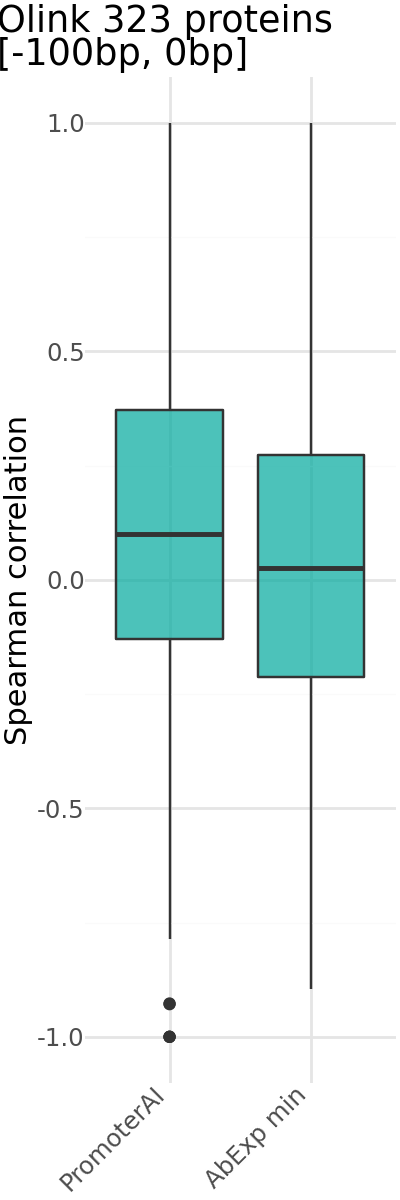

In [102]:
med_df = filt_corr_df.drop_nans().group_by("annotation").agg([
    pl.col("corr_beta").median().alias("median_abs_corr"),
])

corr_pd = med_df.join(filt_corr_df, on='annotation').to_pandas()

corr_pd['label'] = pd.Categorical(
    corr_pd['label'],
    categories=corr_pd.sort_values('median_abs_corr', ascending=False)['label'].unique(),
    ordered=True
)

color_dict = dict(zip(corr_pd['annotation'], corr_pd['color']))

# Plot
(
    ggplot(corr_pd, aes(x="label", y="corr_beta", fill="annotation")) +
    geom_boxplot(alpha=0.7) +
    theme_minimal() +
    scale_fill_manual(values=color_dict) +
    # lims(
    #     y=(-0.25, 0.25)
    # ) +
    labs(
        x="",
        y="Spearman correlation",
        title=f"Olink {len(corr_pd['region'].unique())} proteins \
            \n[{min_range}bp, {max_range}bp]"
            # \nsplice donor/acceptor variants"
    ) +
    theme(
        figure_size=(2, 6),
        legend_position="none",
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

In [103]:
import itertools
from scipy.stats import wilcoxon

annotations = filt_corr_df.select(pl.col("annotation")).unique().to_series().to_list()
pairs = list(itertools.combinations(annotations, 2))

results = []
for a, b in pairs:
    # Subset to same gene-trait pairs where both VSMs have values
    df_a = filt_corr_df.filter(pl.col("annotation") == a).select(["region", "corr_beta"])
    df_b = filt_corr_df.filter(pl.col("annotation") == b).select(["region", "corr_beta"])

    merged = df_a.join(df_b, on=["region"], how="inner", suffix="_b")

    if merged.height > 0:
        stat, pval = wilcoxon(merged["corr_beta"].to_numpy(), merged["corr_beta_b"].to_numpy(), alternative="two-sided")
        results.append((a, b, merged.height, stat, pval))

# Make results dataframe
stats_df = pl.DataFrame(
    results,
    schema=["VSM_A", "VSM_B", "N_pairs", "W_stat", "pval_raw"]
)

stats_df.filter(pl.col("pval_raw") < 0.05).sort("pval_raw")
# stats_df.sort("pval_raw")

/tmp/ipykernel_23044/863415217.py:20: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.


VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""promoterai""","""abexp_min""",323,20646.0,0.003112
